# ⚙️ SVM Analysis

Binary classification task: predict loan approval using **Support Vector Machine (SVM)** classifiers.

SVMs are effective for high-dimensional spaces and perform well when a clean decision boundary separates classes. We explore `linear` and `rbf` kernels with hyperparameter tuning via GridSearchCV.

**Notebook outline:**
1. Objective
2. Import Libraries
3. Import Custom Modules
4. Load Dataset
5. Basic Cleaning
6. Feature Engineering
7. Feature Selection
8. Train-Test Split
9. Build SVM Pipeline
10. Hyperparameter Tuning
11. Evaluation
12. ROC Curve
13. Confusion Matrix
14. Feature Comparison
15. Save Model
16. Conclusion

## 1. Objective

Train and evaluate **Support Vector Machine (SVM)** classifiers to predict whether an HDFC loan application will be **Approved** or **Rejected**.

Key goals:
- Compare `linear` and `rbf` SVM kernels
- Tune `C` (regularisation) and `gamma` (RBF kernel coefficient) via GridSearchCV
- Evaluate using accuracy, precision, recall, F1, ROC-AUC, and confusion matrix
- Compare the best SVM against the baseline from Notebook 02

## 2. Import Libraries

Load standard libraries and configure warnings.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

## 3. Import Custom Modules

Add the project root to the path and import all shared utility modules.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *
from src.utils import *

## 4. Load Dataset

Load the enriched HDFC loan dataset from the `dataset/` directory.

In [3]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 47)


,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


## 5. Basic Cleaning

Remove duplicate rows and strip whitespace from column names.

In [4]:
df = basic_cleaning(df)

print_summary(df)

DataFrame Summary
  Total Rows          : 1000
  Total Columns       : 47
  Numerical Columns   : 20
  Categorical Columns : 27
  Duplicate Rows      : 0
  Missing Values      : 1033


In [5]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


## 6. Feature Engineering

Engineer domain-specific features using `src/feature_engineering.py`:
- `Total_Income` — applicant + co-applicant income
- `EMI_Income_Ratio` — existing EMIs relative to total income
- `Loan_Income_Ratio` — requested loan relative to total income

In [6]:
df = create_features(df)

df[[
    "Total_Income",
    "EMI_Income_Ratio",
    "Loan_Income_Ratio"
]].describe()

,Total_Income,EMI_Income_Ratio,Loan_Income_Ratio
count,1000.000000,1000.000000,1.000000e+03
mean,52157.171000,148.117564,3.661980e+04
std,39371.208558,1974.599120,4.153551e+05
min,0.000000,0.000000,4.110575e-02
25%,21996.000000,0.031200,7.749090e+00
50%,45937.000000,0.332369,2.770369e+01
75%,71379.000000,0.794756,9.991525e+01
max,212945.000000,38342.000000,6.829828e+06


## 7. Feature Selection

Select the predictor columns and encode the binary target `Loan_Status`.

We use the same feature set as Notebook 02 for direct model comparability.

In [7]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "Loan_Status"

In [8]:
x, y = select_features(
    df,
    features,
    target
)

le = LabelEncoder()
y  = le.fit_transform(y)

print("Classes      :", le.classes_)
print("Feature shape:", x.shape)

Classes      : ['Approved' 'Rejected']
Feature shape: (1000, 13)


In [9]:
num_features, cat_features = get_feature_types(x)

preprocessor = create_preprocessor(
    num_features,
    cat_features
)

## 8. Train-Test Split

Split 80/20 with stratification to preserve class balance in both sets.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (800, 13)
Testing Shape  : (200, 13)


## 9. Build SVM Pipeline

Build two baseline SVM pipelines — **linear** and **RBF** kernel — using `build_pipeline` from `src/train.py`.

> `probability=True` enables `predict_proba`, which is required for ROC curve computation.

In [11]:
svm_linear = build_pipeline(
    preprocessor,
    SVC(
        kernel="linear",
        probability=True,
        random_state=42
    )
)

In [12]:
svm_rbf = build_pipeline(
    preprocessor,
    SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    )
)

In [13]:
svm_linear.fit(x_train, y_train)
svm_rbf.fit(x_train, y_train)

linear_pred = predict(svm_linear, x_test)
rbf_pred    = predict(svm_rbf,    x_test)

print("Linear SVM fitted")
print("RBF SVM fitted")

Linear SVM fitted
RBF SVM fitted


In [14]:
linear_results = evaluate_classification(
    y_test,
    linear_pred,
    "SVM Linear"
)
linear_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM Linear,0.81,0.80788,0.81,0.808593


In [15]:
rbf_results = evaluate_classification(
    y_test,
    rbf_pred,
    "SVM RBF"
)
rbf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM RBF,0.83,0.828199,0.83,0.828741


## 10. Hyperparameter Tuning

Tune the SVM over `C`, `gamma`, and `kernel` using `GridSearchCV` with 5-fold CV, optimising for **ROC-AUC**.

| Parameter | Values | Notes |
|-----------|--------|-------|
| `C`       | 0.1, 1, 10, 100 | Regularisation — higher values fit training data tighter |
| `gamma`   | scale, auto, 0.01, 0.001 | RBF kernel width |
| `kernel`  | linear, rbf | Kernel type |

In [16]:
svm_pipeline = build_pipeline(
    preprocessor,
    SVC(
        probability=True,
        random_state=42
    )
)

svm_params = {
    "classifier__C"     : [0.1, 1, 10, 100],
    "classifier__kernel": ["linear", "rbf"],
    "classifier__gamma" : ["scale", "auto", 0.01, 0.001]
}

In [17]:
grid_svm = perform_grid_search(
    pipeline=svm_pipeline,
    parameters=svm_params,
    x_train=x_train,
    y_train=y_train,
    scoring="roc_auc",
    cv=5
)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV ROC-AUC: {:.4f}".format(grid_svm.best_score_))

Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV ROC-AUC: 0.9350


In [18]:
best_svm  = grid_svm.best_estimator_

best_pred = predict(
    best_svm,
    x_test
)

## 11. Evaluation

Evaluate the tuned SVM and compare all three SVM variants.

In [19]:
best_results = evaluate_classification(
    y_test,
    best_pred,
    "SVM Tuned"
)
best_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM Tuned,0.825,0.822423,0.825,0.822601


In [20]:
print_classification_report(
    y_test,
    best_pred
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       131
           1       0.77      0.70      0.73        69

    accuracy                           0.82       200
   macro avg       0.81      0.79      0.80       200
weighted avg       0.82      0.82      0.82       200



In [21]:
comparison = compare_models(
    [linear_results, rbf_results, best_results],
    names=["SVM Linear", "SVM RBF", "SVM Tuned"]
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
SVM Linear,SVM Linear,0.810,0.807880,0.810,0.808593
SVM RBF,SVM RBF,0.830,0.828199,0.830,0.828741
SVM Tuned,SVM Tuned,0.825,0.822423,0.825,0.822601


## 12. ROC Curve

Plot the ROC curve for the best tuned SVM. A higher AUC indicates better discrimination between approved and rejected applications.

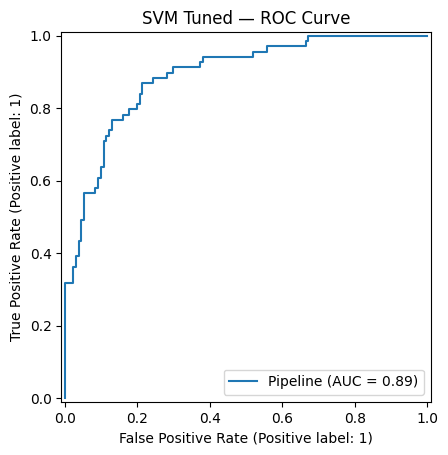

In [22]:
plot_roc_curve(
    best_svm,
    x_test,
    y_test,
    "SVM Tuned — ROC Curve"
)

## 13. Confusion Matrix

Visualise prediction breakdown: true positives, true negatives, false positives, and false negatives.

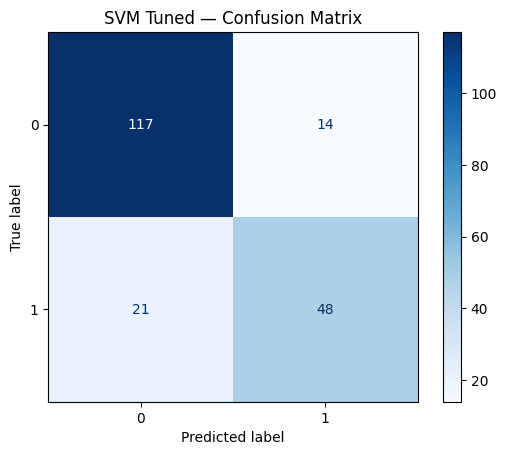

In [23]:
plot_confusion_matrix(
    y_test,
    best_pred,
    "SVM Tuned — Confusion Matrix"
)

## 14. Feature Comparison

SVMs do not expose `feature_importances_` directly. For the **linear kernel**, we extract the decision boundary **coefficients** to rank feature influence.

Positive coefficients push toward approval; negative coefficients push toward rejection.

In [24]:
# Fit a dedicated linear SVM to extract interpretable coefficients
svm_coef_pipeline = build_pipeline(
    preprocessor,
    SVC(
        kernel="linear",
        C=1,
        probability=True,
        random_state=42
    )
)

svm_coef_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
feature_names = svm_coef_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = svm_coef_pipeline.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": coefficients
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient
5,num__Existing_EMIs,1.073957
7,num__Total_Income,-0.745180
0,num__Applicant_Income,-0.731619
3,num__Credit_History,-0.662905
2,num__Loan_Amount,0.660102
6,num__Debt_to_Income_Ratio,0.464286
9,num__EMI_Income_Ratio,0.464265
1,num__Coapplicant_Income,-0.430481
4,num__CIBIL_Score,-0.322748
10,cat__Employment_Status_Retired,0.202187


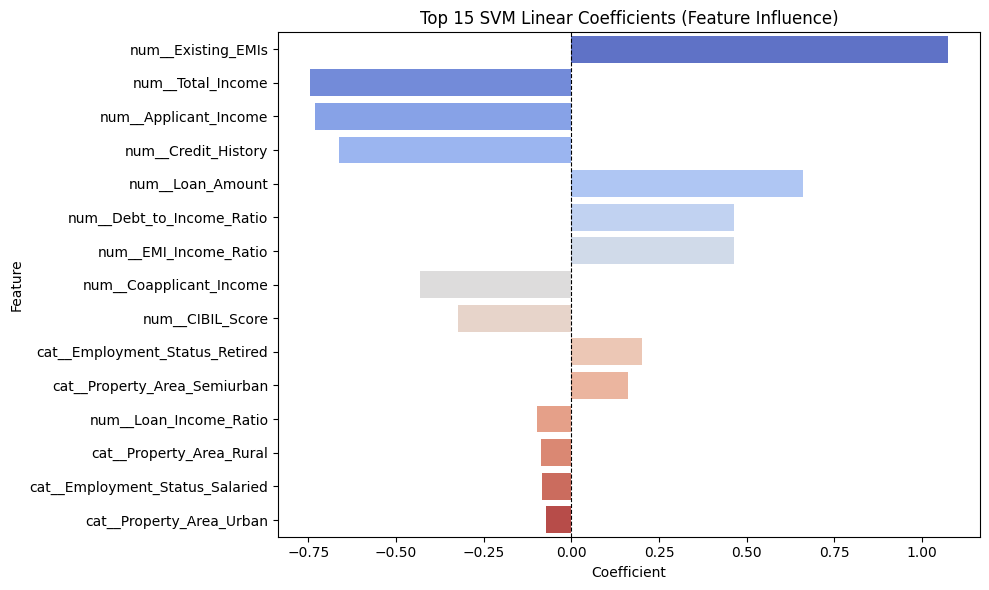

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_df.head(15),
    x="Coefficient",
    y="Feature",
    palette="coolwarm"
)

plt.title("Top 15 SVM Linear Coefficients (Feature Influence)")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

## 15. Save Model

Persist the best tuned SVM pipeline to disk using `joblib`.

In [27]:
save_model(
    best_svm,
    "../models/svm_model.pkl"
)

Model saved → ../models/svm_model.pkl


## 16. Conclusion

### Summary

| Model | Notes |
|-------|-------|
| SVM Linear (baseline) | Fast, interpretable via coefficients |
| SVM RBF (baseline)    | Better for non-linear boundaries |
| SVM Tuned (GridSearch)| Best CV ROC-AUC across `C`, `gamma`, and `kernel` |